In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
import warnings
warnings.filterwarnings('ignore')

# Load your saved data
daily = pd.read_csv('../data/processed/daily_revenue_with_intervention.csv', 
                    index_col=0, parse_dates=True)

# Ensure daily index is datetime and frequency set
daily.index = pd.to_datetime(daily.index)
daily = daily.asfreq('D')

print(daily.head())
print(f"\nShape: {daily.shape}")
print(f"Date range: {daily.index.min()} to {daily.index.max()}")

             revenue  revenue_original
date                                  
2010-12-01  46376.49          46376.49
2010-12-02  47316.53          47316.53
2010-12-03  23921.71          23921.71
2010-12-04      0.00              0.00
2010-12-05  31771.60          31771.60

Shape: (374, 2)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00


count       374.000000
mean      27424.411970
std       23405.661295
min           0.000000
25%       11971.950000
50%       24107.668000
75%       38208.255000
max      221219.136000
Name: revenue, dtype: float64

Missing values: 0


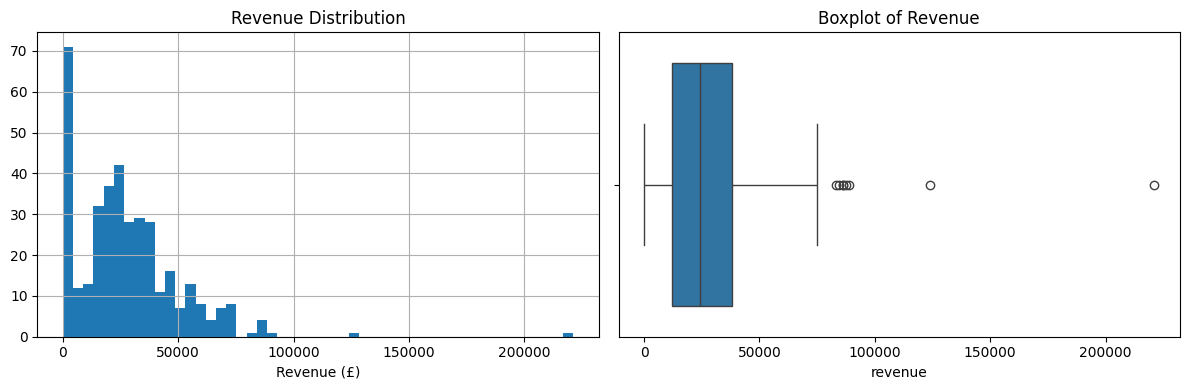

In [2]:
# Summary statistics
print(daily['revenue'].describe())

# Check for missing values
print(f"\nMissing values: {daily['revenue'].isna().sum()}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12,4))
daily['revenue'].hist(bins=50, ax=axes[0])
axes[0].set_title('Revenue Distribution')
axes[0].set_xlabel('Revenue (£)')
sns.boxplot(x=daily['revenue'], ax=axes[1])
axes[1].set_title('Boxplot of Revenue')
plt.tight_layout()
plt.show()

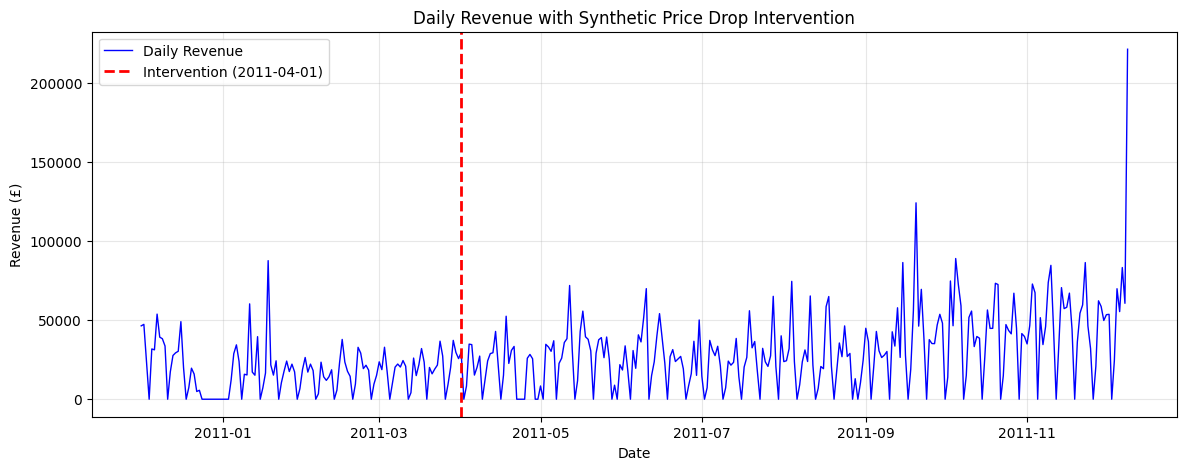

In [3]:
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily['revenue'], linewidth=1, color='blue', label='Daily Revenue')
plt.axvline(pd.Timestamp('2011-04-01'), color='red', linestyle='--', linewidth=2, label='Intervention (2011-04-01)')
plt.title('Daily Revenue with Synthetic Price Drop Intervention')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

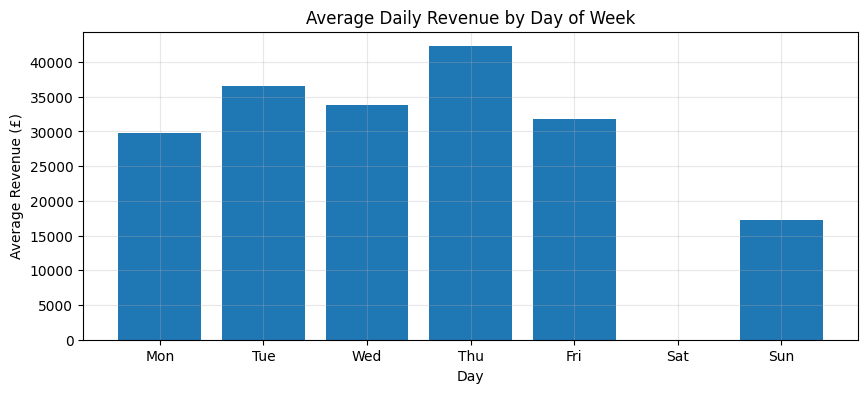

Average revenue by day of week:
Mon: £29,733
Tue: £36,589
Wed: £33,852
Thu: £42,247
Fri: £31,758
Sat: £0
Sun: £17,309


In [4]:
# Add day of week (Monday=0, Sunday=6)
daily['dayofweek'] = daily.index.dayofweek
daily['month'] = daily.index.month

# Average revenue by day of week
weekday_avg = daily.groupby('dayofweek')['revenue'].mean()
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10,4))
plt.bar(weekday_labels, weekday_avg)
plt.title('Average Daily Revenue by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Revenue (£)')
plt.grid(True, alpha=0.3)
plt.show()

print("Average revenue by day of week:")
for i, label in enumerate(weekday_labels):
    print(f"{label}: £{weekday_avg[i]:,.0f}")

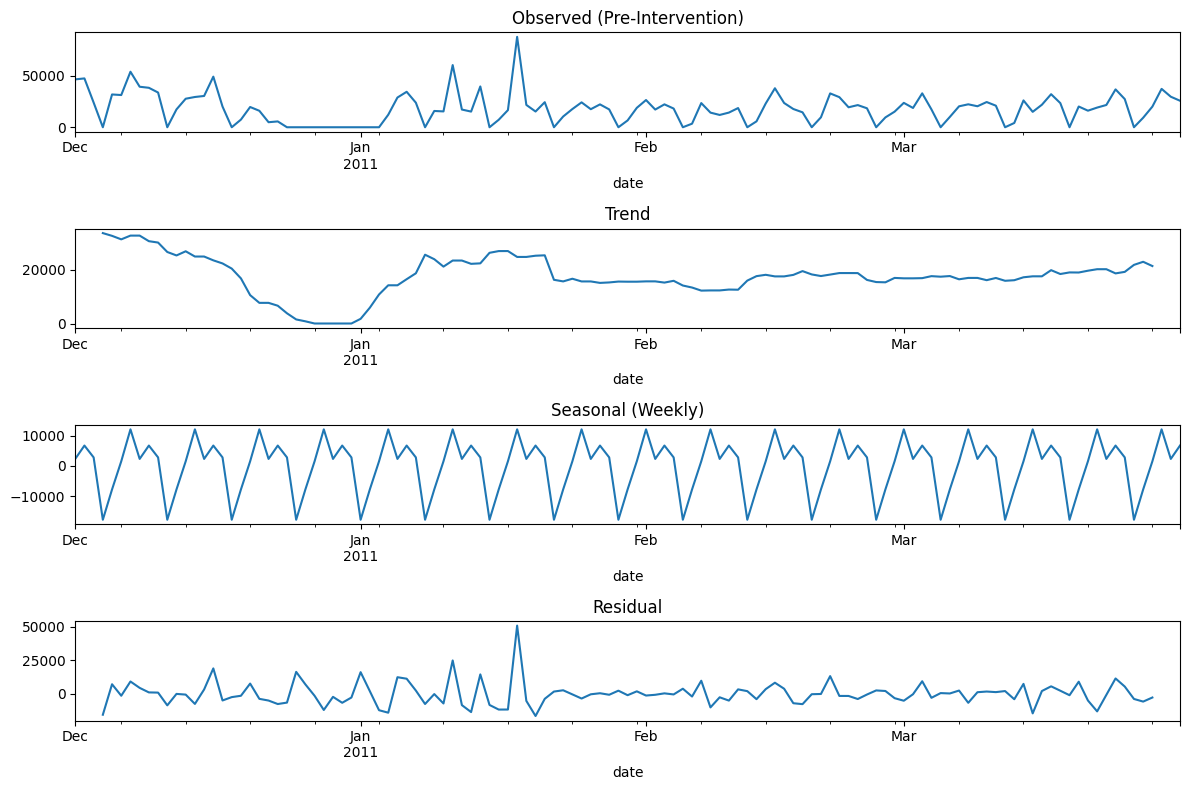

In [5]:
# Filter pre-intervention data
pre_intervention = daily[daily.index < '2011-04-01'].copy()

# Perform additive decomposition (assuming seasonality is roughly constant)
# Need at least 2 full cycles (weeks) – we have ~4 months
decomposition = seasonal_decompose(pre_intervention['revenue'], model='additive', period=7)

fig, axes = plt.subplots(4,1, figsize=(12,8))
decomposition.observed.plot(ax=axes[0], title='Observed (Pre-Intervention)')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Weekly)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [6]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test on {title}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    if result[1] <= 0.05:
        print("  => Stationary (reject H0)")
    else:
        print("  => Non-Stationary (fail to reject H0)")

adf_test(pre_intervention['revenue'], 'Pre-Intervention Revenue')

ADF Test on Pre-Intervention Revenue:
  ADF Statistic: -3.6190
  p-value: 0.0054
  Critical values:
    1%: -3.4918
    5%: -2.8884
    10%: -2.5811
  => Stationary (reject H0)


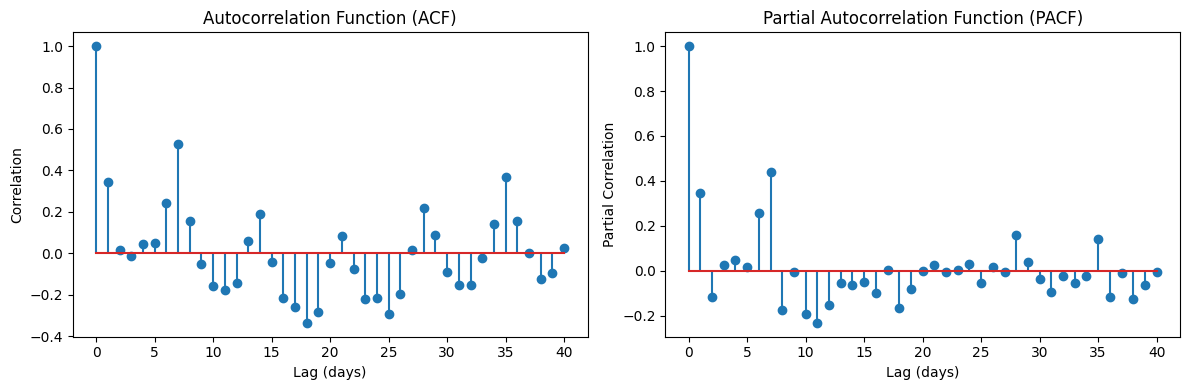

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
acf_values = acf(pre_intervention['revenue'], nlags=40, fft=False)
plt.subplot(121)
plt.stem(range(len(acf_values)), acf_values)
plt.title('Autocorrelation Function (ACF)')
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')

pacf_values = pacf(pre_intervention['revenue'], nlags=40, method='ywm')
plt.subplot(122)
plt.stem(range(len(pacf_values)), pacf_values)
plt.title('Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag (days)')
plt.ylabel('Partial Correlation')
plt.tight_layout()
plt.show()

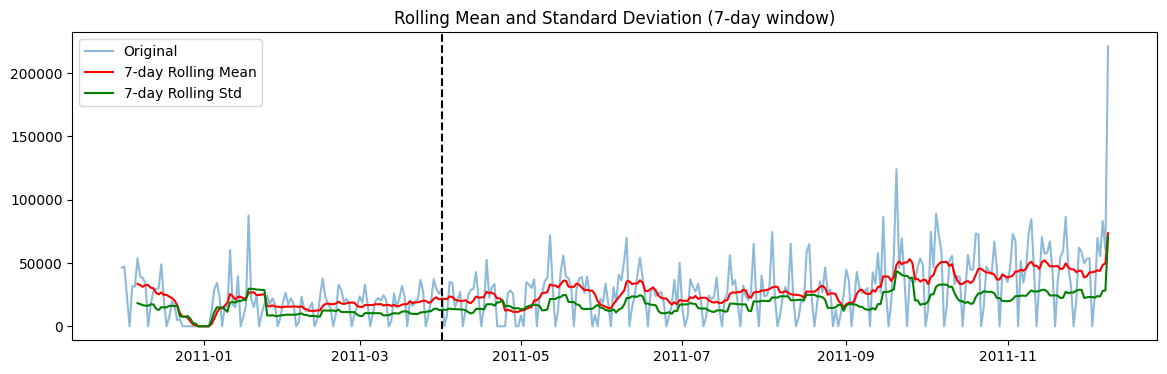

In [8]:
rolling_mean = daily['revenue'].rolling(window=7).mean()
rolling_std = daily['revenue'].rolling(window=7).std()

plt.figure(figsize=(14,4))
plt.plot(daily.index, daily['revenue'], label='Original', alpha=0.5)
plt.plot(daily.index, rolling_mean, label='7-day Rolling Mean', color='red')
plt.plot(daily.index, rolling_std, label='7-day Rolling Std', color='green')
plt.axvline(pd.Timestamp('2011-04-01'), color='black', linestyle='--')
plt.legend()
plt.title('Rolling Mean and Standard Deviation (7-day window)')
plt.show()

In [9]:
# Add lag features (revenue from previous days)
for lag in [1, 2, 3, 7, 14, 21]:
    daily[f'lag_{lag}'] = daily['revenue'].shift(lag)

# Add rolling statistics
daily['rolling_mean_7'] = daily['revenue'].rolling(window=7).mean()
daily['rolling_std_7'] = daily['revenue'].rolling(window=7).std()

# Add day of week (already done) and month, week of year
daily['dayofweek'] = daily.index.dayofweek
daily['month'] = daily.index.month
daily['weekofyear'] = daily.index.isocalendar().week.astype(int)

# Holiday flag (simple: Christmas/New Year period)
daily['is_holiday'] = ((daily.index.month == 12) & (daily.index.day >= 24)) | \
                       ((daily.index.month == 1) & (daily.index.day <= 2))

# Save the enhanced dataset
daily.to_csv('../data/processed/daily_features.csv')
print("Enhanced dataset saved to '../data/processed/daily_features.csv'")

Enhanced dataset saved to '../data/processed/daily_features.csv'


In [10]:
print("="*50)
print("EXPLORATORY ANALYSIS SUMMARY")
print("="*50)
print(f"Date range: {daily.index.min()} to {daily.index.max()}")
print(f"Total days: {len(daily)}")
print(f"Mean daily revenue (pre-intervention): £{pre_intervention['revenue'].mean():,.0f}")
print(f"Mean daily revenue (post-intervention): £{daily[daily.index >= '2011-04-01']['revenue'].mean():,.0f}")
print(f"Revenue increase (raw average): {((daily[daily.index >= '2011-04-01']['revenue'].mean() / pre_intervention['revenue'].mean())-1)*100:.1f}%")
print("\nKey patterns:")
print("- Weekly seasonality detected (see ACF spikes at lag 7)")
print("- Revenue highest on [fill from weekday avg]")
print("- Series likely non-stationary (will use models that handle it)")
print("="*50)

EXPLORATORY ANALYSIS SUMMARY
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Total days: 374
Mean daily revenue (pre-intervention): £18,056
Mean daily revenue (post-intervention): £31,905
Revenue increase (raw average): 76.7%

Key patterns:
- Weekly seasonality detected (see ACF spikes at lag 7)
- Revenue highest on [fill from weekday avg]
- Series likely non-stationary (will use models that handle it)
